# Joint Multi-band Deconvolution of CFHT and Euclid images

In [1]:
import torch
import sys
sys.path.insert(0, '/Users/utsavakhaury/Thesis/Multichannel_Deconv/')
from DPIR.models.network_unet import UNetRes as net
from skimage.restoration import estimate_sigma

import numpy as np
import matplotlib.pyplot as plt
from MBDeconv_FISTA import *
from astropy.io import fits
from skimage.transform import resize
from matplotlib.colors import SymLogNorm
import pickle
import scarlet

### Utility Functions

In [2]:
# Resize image while conserving flux
def resize_conserve_flux(img, size):
    orig_size = img.shape[0]
    img = resize(img, size, anti_aliasing=True)
    return img / (size[0]/orig_size)**2

### Load PSF

In [ ]:
# These PSFs were obtained using PSFEx for a more accurate deconvolution. See: https://github.com/astropy/PSFEx
with open('../Data/psf_49_5319455_41_5224932.pkl', 'rb') as f:
    psf = pickle.load(f)

# Extracting the PSFs for the r, i, and z bands
psf_r = psf[0]
psf_i = psf[1]
psf_z = psf[2]

# Padding the PSFs to make them the same size
psf_r = psf_r
psf_i = np.pad(psf_i, ((6,6), (6,6)), mode='constant')
psf_z = np.pad(psf_z, ((5,5), (5,5)), mode='constant')

# Resize the PSFs to 128x128 while conserving flux
psf_r = resize_conserve_flux(psf_r, (128, 128))
psf_i = resize_conserve_flux(psf_i, (128, 128))
psf_z = resize_conserve_flux(psf_z, (128, 128))

# Normalize the PSFs so that they sum to 1
psf_r /= np.sum(psf_r)
psf_i /= np.sum(psf_i)
psf_z /= np.sum(psf_z)

psf_lsst = np.stack([psf_r, psf_i, psf_z], axis=-1)

# Load the Euclid PSF and normalize it
psf_euc = fits.open('../Data/psf_Euclid_VIS.fits')[0].data
psf_euc /= np.sum(psf_euc)

print(psf_r.shape, psf_i.shape, psf_z.shape, psf_euc.shape)

(128, 128) (128, 128) (128, 128) (128, 128)


### Display CFHT PSFs

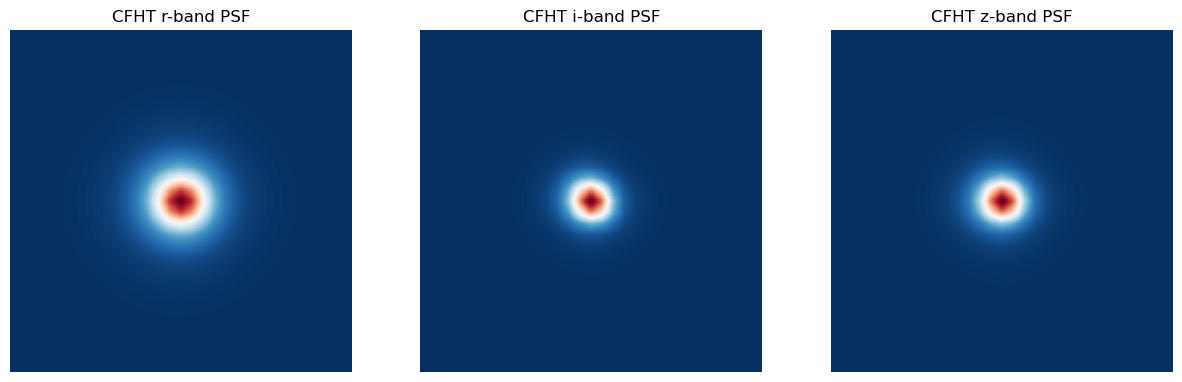

In [4]:
plt.subplots(1,3, figsize=(15,7))
plt.subplot(131)
plt.imshow(psf_r, cmap='RdBu_r'); plt.title('CFHT r-band PSF'); plt.axis('off')
plt.subplot(132)
plt.imshow(psf_i, cmap='RdBu_r'); plt.title('CFHT i-band PSF'); plt.axis('off')
plt.subplot(133)
plt.imshow(psf_z, cmap='RdBu_r'); plt.title('CFHT z-band PSF'); plt.axis('off') 
plt.show()    

### Load Noisy CFHT and Euclid Data

In [5]:
noisy = np.load('../Data/cfht.npy')           # Noisy CFHT images in the 3 bands (32 X 32 in this case)
euclid = np.load('../Data/euc.npy')           # Euclid image in the VIS band (64 X 64 in this case)
sed = np.load('Data/sed.npy')                 # Fractional contribution of the 3 bands to the Euclid image

print(noisy.shape, euclid.shape)

(64, 64, 3) (128, 128)


### Calculate Noisemap using Scarlet

In [6]:
# Function to compute the starlet transform coefficients for each image in the input array
def run_scarlet(arr, scales):
    coeffs_arr = np.zeros((scales+1, arr.shape[0], arr.shape[1], arr.shape[2]))
    for im in range(arr.shape[-1]):
        coeffs_arr[...,im] = scarlet.wavelet.starlet_transform(arr[...,im], scales=scales)
    return coeffs_arr

# Compute the starlet transform coefficients for the noisy and Euclid images using the scarlet library. We use 4 scales in the starlet transform.
scales = 4
scarlet_noisy = run_scarlet(noisy, scales=scales)
scarlet_euclid = run_scarlet(np.expand_dims(euclid, -1), scales=scales)

# Compute the noise level in the starlet domain for each image by taking the average of the standard deviation
# of the coefficients in the 4 corners of the image at the finest scale (scale=0).
noisemap = [np.array(estimate_sigma(scarlet_noisy[0,:10,:10,0]) + estimate_sigma(scarlet_noisy[0,:10,-10:,0]) + 
                     estimate_sigma(scarlet_noisy[0,-10:,:10,0]) + estimate_sigma(scarlet_noisy[0,-10:,-10:,0]))/4,

            np.array(estimate_sigma(scarlet_noisy[0,:10,:10,1]) + estimate_sigma(scarlet_noisy[0,:10,-10:,1]) + 
                     estimate_sigma(scarlet_noisy[0,-10:,:10,1]) + estimate_sigma(scarlet_noisy[0,-10:,-10:,1]))/4,

            np.array(estimate_sigma(scarlet_noisy[0,:10,:10,2]) + estimate_sigma(scarlet_noisy[0,:10,-10:,2]) + 
                     estimate_sigma(scarlet_noisy[0,-10:,:10,2]) + estimate_sigma(scarlet_noisy[0,-10:,-10:,2]))/4,

            np.array(estimate_sigma(scarlet_euclid[0,:20,:20,0]) + estimate_sigma(scarlet_euclid[0,:20,-20:,0]) + 
                     estimate_sigma(scarlet_euclid[0,-20:,:20,0]) + estimate_sigma(scarlet_euclid[0,-20:,-20:,0]))/4]

### Run Multi-band Deconvolution

In [ ]:
mbdeconv = runDeconv(noisy, 
                     euclid, 
                     psf_lsst, 
                     psf_euc, 
                     noisemap, 
                     n_iter=20,              # Number of iterations
                     SED=sed, 
                     frac_contr=0.3)         # Fractional contribution of the constraining term in the loss function found using grid search.

print(mbdeconv.shape)

(128, 128, 3)


### Display outputs after Deconvolution

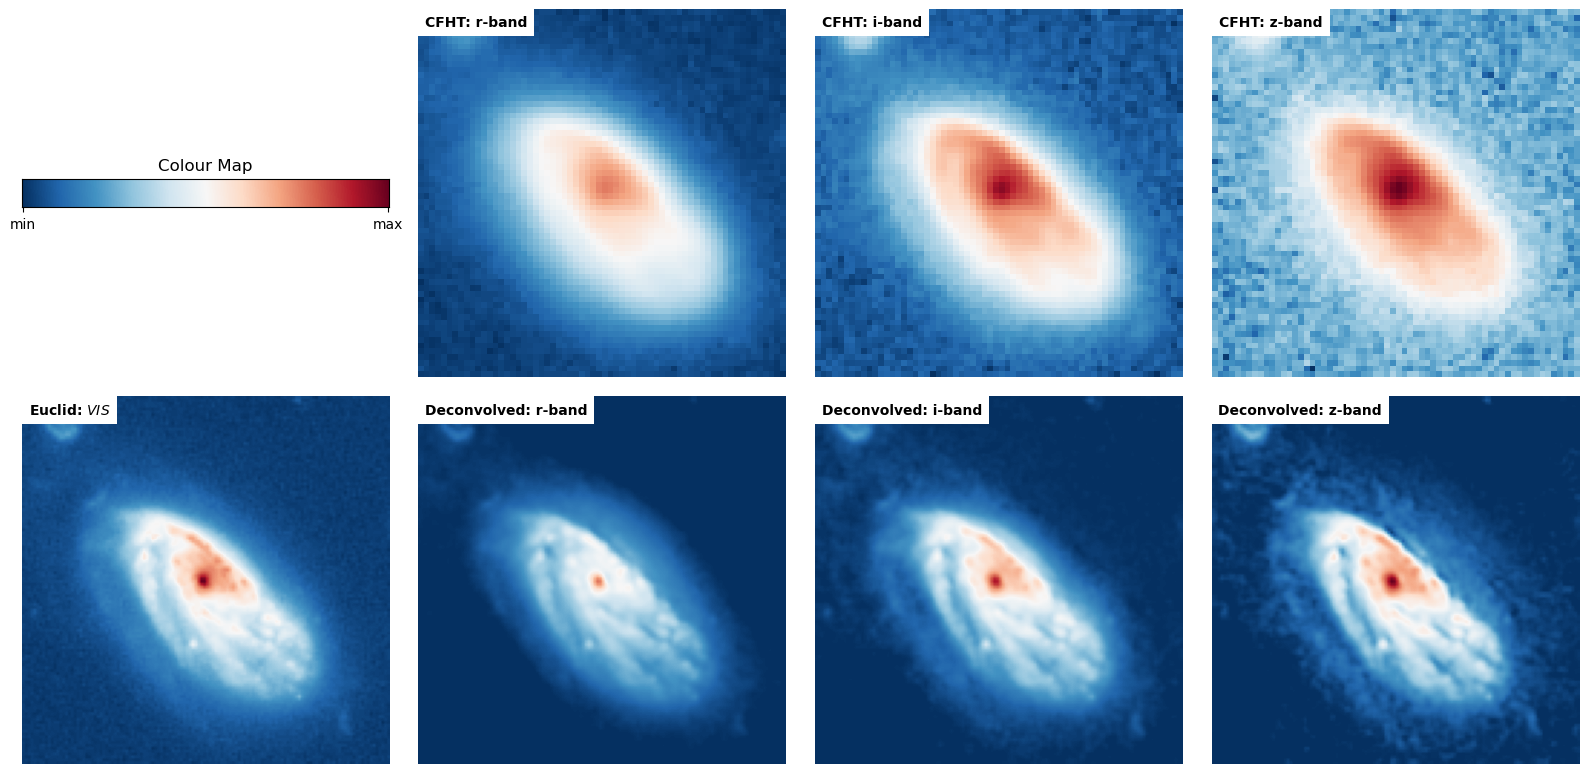

In [8]:
cfht_r = noisy[...,0]
cfht_i = noisy[...,1]
cfht_z = noisy[...,2]
deconv_r = mbdeconv[...,0]
deconv_i = mbdeconv[...,1]
deconv_z = mbdeconv[...,2]

cmap = 'RdBu_r'
fig, axs = plt.subplots(2, 4, figsize=(16,8))
for i,j in np.ndindex(axs.shape):
    if i!=0 or j!=0:
        axs[i,j].axis('off')
        
def scale(arr):
    return np.log10(arr - np.min(arr) + 10)
       
axs[1,0].imshow(scale(euclid), cmap=cmap, origin='lower')
axs[1,0].text(.02, .9425, 'Euclid: $VIS$', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[1,0].transAxes)

vmax_cfht = np.max([np.max(scale(cfht_r)), np.max(scale(cfht_i)), np.max(scale(cfht_z))])
vmin_cfht = np.min([np.min(scale(cfht_r)), np.min(scale(cfht_i)), np.min(scale(cfht_z))])

axs[0,1].imshow(scale(cfht_r), cmap=cmap, origin='lower', vmin=vmin_cfht, vmax=vmax_cfht)
axs[0,1].text(.0175, .945, 'CFHT: r-band', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[0,1].transAxes)

axs[0,2].imshow(scale(cfht_i), cmap=cmap, origin='lower', vmin=vmin_cfht, vmax=vmax_cfht)
axs[0,2].text(.0175, .945, 'CFHT: i-band', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[0,2].transAxes)

axs[0,3].imshow(scale(cfht_z), cmap=cmap, origin='lower', vmin=vmin_cfht, vmax=vmax_cfht)
axs[0,3].text(.02, .945, 'CFHT: z-band', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[0,3].transAxes)

vmax_deconv = np.max([np.max(scale(deconv_r)), np.max(scale(deconv_i)), np.max(scale(deconv_z))])
vmin_deconv = np.min([np.min(scale(deconv_r)), np.min(scale(deconv_i)), np.min(scale(deconv_z))])

axs[1,1].imshow(scale(deconv_r), cmap=cmap, origin='lower', vmin=vmin_deconv, vmax=vmax_deconv)
axs[1,1].text(.0175, .945, 'Deconvolved: r-band', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[1,1].transAxes)

axs[1,2].imshow(scale(deconv_i), cmap=cmap, origin='lower', vmin=vmin_deconv, vmax=vmax_deconv)
axs[1,2].text(.0175, .945, 'Deconvolved: i-band', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[1,2].transAxes)

axs[1,3].imshow(scale(deconv_z), cmap=cmap, origin='lower', vmin=vmin_deconv, vmax=vmax_deconv)
axs[1,3].text(.0175, .945, 'Deconvolved: z-band', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[1,3].transAxes)

axs[0,0].set_title('Colour Map', fontsize=12)
axs[0,0].imshow(np.rot90(np.arange(128*10).reshape(128, 10)), cmap=cmap)
axs[0,0].set_xticks([0, 127], labels=['min', 'max'])
axs[0,0].set_yticks([])

plt.tight_layout()
plt.show()

# Denoising using DRUNet

In [9]:
n_channels = 1  
drunet_model_path = '/Users/utsavakhaury/Thesis/Multichannel_Deconv/DPIR/model_zoo/drunet_gray.pth'

drunet_model = net(in_nc=n_channels+1, out_nc=n_channels, nc=[64, 128, 256, 512], nb=4, act_mode='R', downsample_mode="strideconv", upsample_mode="convtranspose")
drunet_model.load_state_dict(torch.load(drunet_model_path), strict=True)
drunet_model.eval()
for k, v in drunet_model.named_parameters():
    v.requires_grad = False
drunet_model = drunet_model.to('cpu')
number_parameters = sum(map(lambda x: x.numel(), drunet_model.parameters()))

### Estimate noismap for Denoising

In [ ]:
deconv_noisemap = np.zeros((mbdeconv.shape))
res_drunet = np.zeros((mbdeconv.shape))

# Compute the noise level in the deconvolved images for each image by taking the average of the standard deviation of the coefficients 
# in the 4 corners of the image at the finest scale (scale=0) of the starlet transform of the deconvolved images. 
scarlet_deconv = run_scarlet(mbdeconv, scales=scales)
scarlet_deconv[scarlet_deconv == 0] = 1e-10
for j in range(mbdeconv.shape[-1]):
    deconv_noisemap[...,j] = np.array(estimate_sigma(scarlet_deconv[0,:10,:10,j]) + estimate_sigma(scarlet_deconv[0,:10,-10:,j]) + 
                                      estimate_sigma(scarlet_deconv[0,-10:,:10,j]) + estimate_sigma(scarlet_deconv[0,-10:,-10:,j]))/4
                
# Denoise the deconvolved images using the DRUNet model. The input to the model is a 4-channel image consisting of the deconvolved image and the noise map, 
# and the output is the denoised image in the 3 bands.
for ch in range(res_drunet.shape[-1]):
    res_drunet[...,ch] = drunet_model(torch.FloatTensor(np.expand_dims(np.vstack((np.expand_dims(mbdeconv[...,ch], -1).T, 
                                                        np.expand_dims(deconv_noisemap[...,ch], -1).T)).T, 0)).permute(0,3,1,2)).permute(0,2,3,1).detach().numpy().squeeze()

### Display ouputs after Denoising

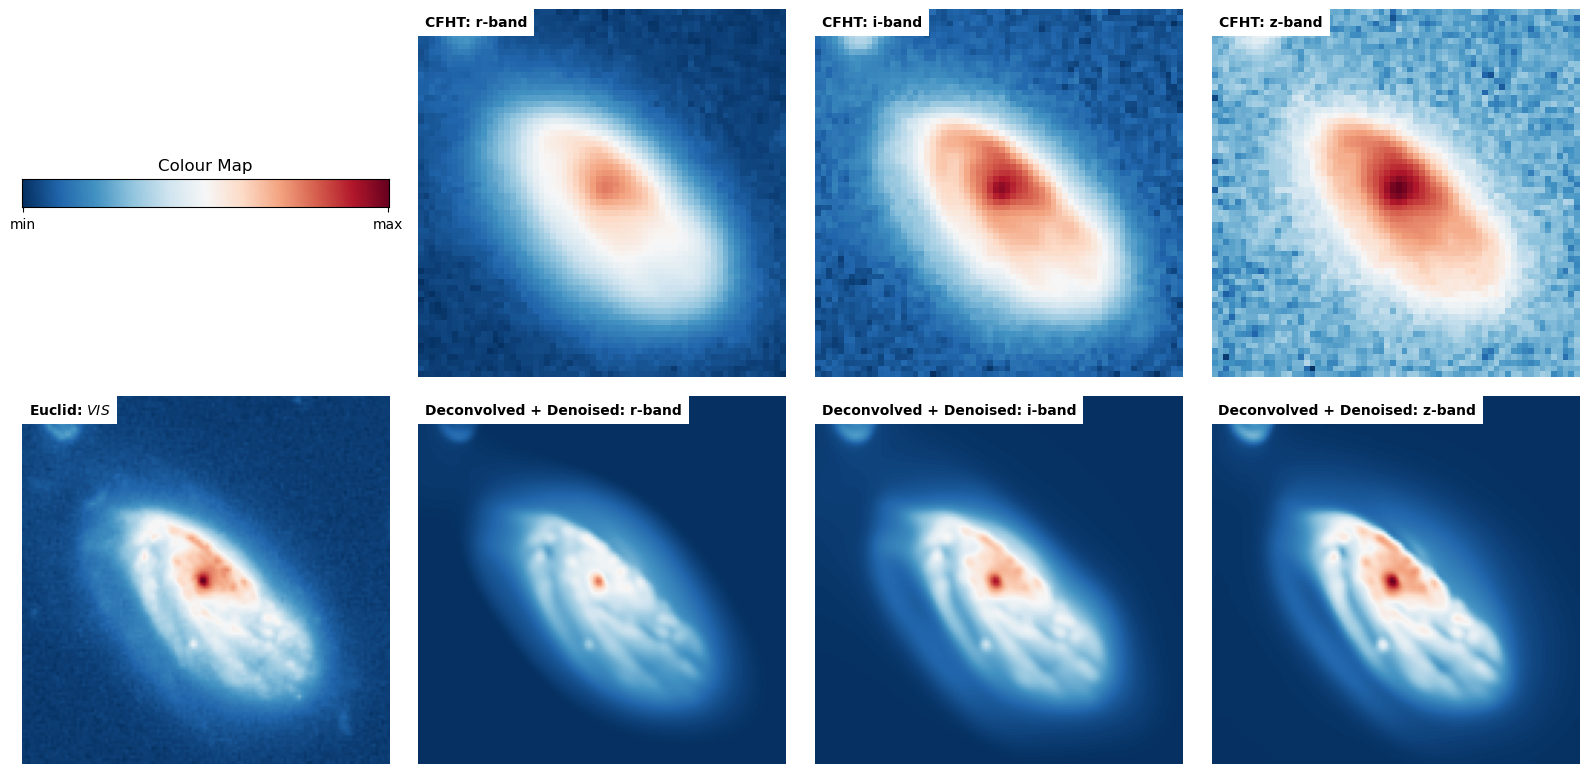

In [11]:
cmap = 'RdBu_r'
fig, axs = plt.subplots(2, 4, figsize=(16,8))
for i,j in np.ndindex(axs.shape):
    if i!=0 or j!=0:
        axs[i,j].axis('off')
        
def scale(arr):
    return np.log10(arr - np.min(arr) + 10)
       
axs[1,0].imshow(scale(euclid), cmap=cmap, origin='lower')
axs[1,0].text(.02, .9425, 'Euclid: $VIS$', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[1,0].transAxes)

vmax_cfht = np.max([np.max(scale(cfht_r)), np.max(scale(cfht_i)), np.max(scale(cfht_z))])
vmin_cfht = np.min([np.min(scale(cfht_r)), np.min(scale(cfht_i)), np.min(scale(cfht_z))])

axs[0,1].imshow(scale(cfht_r), cmap=cmap, origin='lower', vmin=vmin_cfht, vmax=vmax_cfht)
axs[0,1].text(.0175, .945, 'CFHT: r-band', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[0,1].transAxes)

axs[0,2].imshow(scale(cfht_i), cmap=cmap, origin='lower', vmin=vmin_cfht, vmax=vmax_cfht)
axs[0,2].text(.0175, .945, 'CFHT: i-band', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[0,2].transAxes)

axs[0,3].imshow(scale(cfht_z), cmap=cmap, origin='lower', vmin=vmin_cfht, vmax=vmax_cfht)
axs[0,3].text(.02, .945, 'CFHT: z-band', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[0,3].transAxes)

vmax_deconv = np.max([np.max(scale(res_drunet[...,0])), np.max(scale(res_drunet[...,1])), np.max(scale(res_drunet[...,2]))])
vmin_deconv = np.min([np.min(scale(res_drunet[...,0])), np.min(scale(res_drunet[...,1])), np.min(scale(res_drunet[...,2]))])

axs[1,1].imshow(scale(res_drunet[...,0]), cmap=cmap, origin='lower', vmin=vmin_deconv, vmax=vmax_deconv)
axs[1,1].text(.0175, .945, 'Deconvolved + Denoised: r-band', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[1,1].transAxes)

axs[1,2].imshow(scale(res_drunet[...,1]), cmap=cmap, origin='lower', vmin=vmin_deconv, vmax=vmax_deconv)
axs[1,2].text(.0175, .945, 'Deconvolved + Denoised: i-band', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[1,2].transAxes)

axs[1,3].imshow(scale(res_drunet[...,2]), cmap=cmap, origin='lower', vmin=vmin_deconv, vmax=vmax_deconv)
axs[1,3].text(.0175, .945, 'Deconvolved + Denoised: z-band', ha='left', va='bottom', fontsize=10, fontweight="bold", color='black', bbox={'facecolor': 'white', 'alpha': 1, 'pad': 5, 'edgecolor': 'none'}, transform=axs[1,3].transAxes)

axs[0,0].set_title('Colour Map', fontsize=12)
axs[0,0].imshow(np.rot90(np.arange(128*10).reshape(128, 10)), cmap=cmap)
axs[0,0].set_xticks([0, 127], labels=['min', 'max'])
axs[0,0].set_yticks([])

plt.tight_layout()
plt.show()